In [49]:
"""A small local few-shot classifier using sentence embeddings."""

import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sentence_transformers import SentenceTransformer, util
from pathlib import Path

In [50]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
MODEL_2 = "sentence-transformers/all-mpnet-base-v2"

In [ ]:
data = pd.read_excel("datasets/product_classified_Full.xlsx", sheet_name="in")

In [52]:
# Selecting relevant columns for analysis
independent_cols = ["ProductDescription", "GPCBrickCode", "UNSPSCNumber"]
target_cols = ["ProductGroup", "ProductFamily", "ProductType", "ProductKey", "ProductLine"]

In [53]:
# dataset with only the independent and target columns
dataset = data[independent_cols + target_cols]

In [54]:
dataset.shape

(10237, 8)

In [55]:
# Checking how many rows has all NaN in the independent columns
dataset[dataset["ProductDescription"].isna() & dataset["GPCBrickCode"].isna() & dataset["UNSPSCNumber"].isna()].shape[0]

650

In [56]:
# Checking how many rows has NaN in each of the columns
dataset.isna().sum()

ProductDescription    6325
GPCBrickCode          1299
UNSPSCNumber          1478
ProductGroup             0
ProductFamily            0
ProductType              0
ProductKey               0
ProductLine              0
dtype: int64

In [57]:
dataset['ProductDescription'] = dataset['ProductDescription'].fillna('')
dataset['GPCBrickCode'] = dataset['GPCBrickCode'].fillna('Unknown_GPCBrickCode')
dataset['UNSPSCNumber'] = dataset['UNSPSCNumber'].fillna('Unknown_UNSPSCNumber')

In [58]:
# Checking how many rows has NaN in each of the columns
dataset.isna().sum()

ProductDescription    0
GPCBrickCode          0
UNSPSCNumber          0
ProductGroup          0
ProductFamily         0
ProductType           0
ProductKey            0
ProductLine           0
dtype: int64

In [59]:
# Combining the three columns into a single text column for embedding
columns_to_embed = ["ProductDescription", "GPCBrickCode", "UNSPSCNumber"]
    
dataset['combined_text'] = [
    f"{columns_to_embed[0]}: {col1} | {columns_to_embed[1]}: {col2} | {columns_to_embed[2]}: {col3}"
    for col1, col2, col3 in zip(
        dataset[columns_to_embed[0]],
        dataset[columns_to_embed[1]],
        dataset[columns_to_embed[2]]
    )
]

In [60]:
dataset["combined_text"][0]

'ProductDescription:  | GPCBrickCode: Unknown_GPCBrickCode | UNSPSCNumber: Unknown_UNSPSCNumber'

In [61]:
# Encode combined text column with multiple models and save to disk
def encode_texts(dataset, model_names=(MODEL_NAME, MODEL_2), test_size=0.2, random_state=42):
    """ACCEPT_THRESHOLD: Encode the combined text column of the dataset using multiple models and save it to disk."""

    # Split the embedded dataset into training and testing sets
    train_idx, test_idx = train_test_split(dataset.index, test_size=test_size, random_state=random_state)

    encoded = {}
    for model_name in model_names:
        output_dir = Path(model_name)
        embeddings_path = output_dir / "pd_gpc_uns_text_embeddings.npy"

        if embeddings_path.exists():
            print(f"Loading embeddings from {embeddings_path}")
            embeddings = np.load(embeddings_path)
        else:
            print(f"Embeddings not found for {model_name}. Encoding now...")
            model = SentenceTransformer(model_name)
            embeddings = model.encode(
                dataset['combined_text'].tolist(),
                normalize_embeddings=True,
                show_progress_bar=True,
            )
            output_dir.mkdir(parents=True, exist_ok=True)
            np.save(embeddings_path, embeddings)

        encoded[model_name] = (embeddings[train_idx], embeddings[test_idx])

    return encoded, train_idx, test_idx

In [62]:
# define function to compare models using 1-NN with cosine similarity
def compare_models(dataset, target_cols, encoded, train_idx, test_idx):
    """Compare nearest-neighbor accuracy across pre-encoded models for a given target_col."""
    results = []
    for target_col in target_cols:
        train_labels = dataset.loc[train_idx, target_col].tolist()
        test_labels = dataset.loc[test_idx, target_col].tolist()
        label_order = sorted(set(train_labels))

        for model_name, (train_vectors, test_vectors) in encoded.items():
            print(f"=== Model: {model_name} ===")
            nearest_indices = (test_vectors @ train_vectors.T).argmax(axis=1)
            predicted_labels = [train_labels[i] for i in nearest_indices]

            results.append(
                {
                    "Strategy": "Cosine Similarity (1-NN)",
                    "Model": model_name,
                    "target_col": target_col,
                    "Accuracy": accuracy_score(test_labels, predicted_labels),
                    "Precision": precision_score(test_labels, predicted_labels, average="macro", zero_division=0),
                    "Recall": recall_score(test_labels, predicted_labels, average="macro", zero_division=0),
                    "F1-Score": f1_score(test_labels, predicted_labels, average="macro", zero_division=0),
                }
            )    

    return results


In [63]:
# get the encoded vectors and train/test indices
encoded, train_idx, test_idx = encode_texts(dataset)

Loading embeddings from sentence-transformers/all-MiniLM-L6-v2/pd_gpc_uns_text_embeddings.npy
Loading embeddings from sentence-transformers/all-mpnet-base-v2/pd_gpc_uns_text_embeddings.npy


In [64]:
# Compare models using 1-NN with cosine similarity
results = compare_models(dataset, target_cols, encoded, train_idx, test_idx)

=== Model: sentence-transformers/all-MiniLM-L6-v2 ===
=== Model: sentence-transformers/all-mpnet-base-v2 ===
=== Model: sentence-transformers/all-MiniLM-L6-v2 ===
=== Model: sentence-transformers/all-mpnet-base-v2 ===
=== Model: sentence-transformers/all-MiniLM-L6-v2 ===
=== Model: sentence-transformers/all-mpnet-base-v2 ===
=== Model: sentence-transformers/all-MiniLM-L6-v2 ===
=== Model: sentence-transformers/all-mpnet-base-v2 ===
=== Model: sentence-transformers/all-MiniLM-L6-v2 ===
=== Model: sentence-transformers/all-mpnet-base-v2 ===


In [65]:
# Display the results as a DataFrame
pd.DataFrame(results)


,Strategy,Model,target_col,Accuracy,Precision,Recall,F1-Score
0,Cosine Similarity (1-NN),sentence-transformers/all-MiniLM-L6-v2,ProductGroup,0.668945,0.649800,0.569525,0.574122
1,Cosine Similarity (1-NN),sentence-transformers/all-mpnet-base-v2,ProductGroup,0.669434,0.647824,0.569643,0.574514
2,Cosine Similarity (1-NN),sentence-transformers/all-MiniLM-L6-v2,ProductFamily,0.560059,0.452971,0.361095,0.359642
3,Cosine Similarity (1-NN),sentence-transformers/all-mpnet-base-v2,ProductFamily,0.563477,0.455028,0.379580,0.365484
4,Cosine Similarity (1-NN),sentence-transformers/all-MiniLM-L6-v2,ProductType,0.570312,0.383922,0.378364,0.356973
5,Cosine Similarity (1-NN),sentence-transformers/all-mpnet-base-v2,ProductType,0.571289,0.377596,0.374560,0.353826
6,Cosine Similarity (1-NN),sentence-transformers/all-MiniLM-L6-v2,ProductKey,0.471191,0.334445,0.301828,0.277253
7,Cosine Similarity (1-NN),sentence-transformers/all-mpnet-base-v2,ProductKey,0.467773,0.324176,0.299434,0.270635
8,Cosine Similarity (1-NN),sentence-transformers/all-MiniLM-L6-v2,ProductLine,0.423828,0.405630,0.330946,0.327202
9,Cosine Similarity (1-NN),sentence-transformers/all-mpnet-base-v2,ProductLine,0.423828,0.405236,0.326433,0.325750


In [66]:
# define function to compare models using k-NN with cosine similarity
import numpy as np
from collections import Counter

def compare_models_knn(dataset, target_cols, encoded, train_idx, test_idx, k=5):
    """k-NN majority-vote classification — more robust than single nearest neighbor (k=1)."""
    knn_results = []
    for target_col in target_cols:
        train_labels = np.array(dataset.loc[train_idx, target_col].tolist())
        test_labels = dataset.loc[test_idx, target_col].tolist()


        for model_name, (train_vectors, test_vectors) in encoded.items():
            print(f"=== Model: {model_name} (k={k}) ===")
            similarities = test_vectors @ train_vectors.T
            top_k_indices = np.argpartition(-similarities, kth=k - 1, axis=1)[:, :k]

            predicted_labels = [
                Counter(train_labels[row_indices]).most_common(1)[0][0]
                for row_indices in top_k_indices
            ]

            knn_results.append(
                {
                    "Strategy": f"cosine similarity kNN (k={k}) majority vote",
                    "Model": model_name,
                    "target_col": target_col,
                    "Accuracy": accuracy_score(test_labels, predicted_labels),
                    "Precision": precision_score(test_labels, predicted_labels, average="macro", zero_division=0),
                    "Recall": recall_score(test_labels, predicted_labels, average="macro", zero_division=0),
                    "F1-Score": f1_score(test_labels, predicted_labels, average="macro", zero_division=0),
                }
            )

    return knn_results




In [67]:
# Compare models using k-NN with cosine similarity
knn_results = compare_models_knn(dataset, target_cols, encoded, train_idx, test_idx, k=5)


=== Model: sentence-transformers/all-MiniLM-L6-v2 (k=5) ===
=== Model: sentence-transformers/all-mpnet-base-v2 (k=5) ===
=== Model: sentence-transformers/all-MiniLM-L6-v2 (k=5) ===
=== Model: sentence-transformers/all-mpnet-base-v2 (k=5) ===
=== Model: sentence-transformers/all-MiniLM-L6-v2 (k=5) ===
=== Model: sentence-transformers/all-mpnet-base-v2 (k=5) ===
=== Model: sentence-transformers/all-MiniLM-L6-v2 (k=5) ===
=== Model: sentence-transformers/all-mpnet-base-v2 (k=5) ===
=== Model: sentence-transformers/all-MiniLM-L6-v2 (k=5) ===
=== Model: sentence-transformers/all-mpnet-base-v2 (k=5) ===


In [68]:
# Display the k-NN results as a DataFrame
pd.DataFrame(knn_results)

,Strategy,Model,target_col,Accuracy,Precision,Recall,F1-Score
0,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-MiniLM-L6-v2,ProductGroup,0.670410,0.651700,0.553992,0.564606
1,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-mpnet-base-v2,ProductGroup,0.711426,0.657565,0.571096,0.592573
2,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-MiniLM-L6-v2,ProductFamily,0.561523,0.429733,0.337562,0.343582
3,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-mpnet-base-v2,ProductFamily,0.515625,0.409739,0.354435,0.339135
4,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-MiniLM-L6-v2,ProductType,0.532715,0.320437,0.287464,0.279674
5,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-mpnet-base-v2,ProductType,0.551270,0.338304,0.315381,0.302418
6,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-MiniLM-L6-v2,ProductKey,0.502441,0.284606,0.268387,0.250507
7,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-mpnet-base-v2,ProductKey,0.517578,0.288617,0.278952,0.260662
8,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-MiniLM-L6-v2,ProductLine,0.422852,0.387988,0.326684,0.313669
9,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-mpnet-base-v2,ProductLine,0.429688,0.365195,0.321627,0.308795


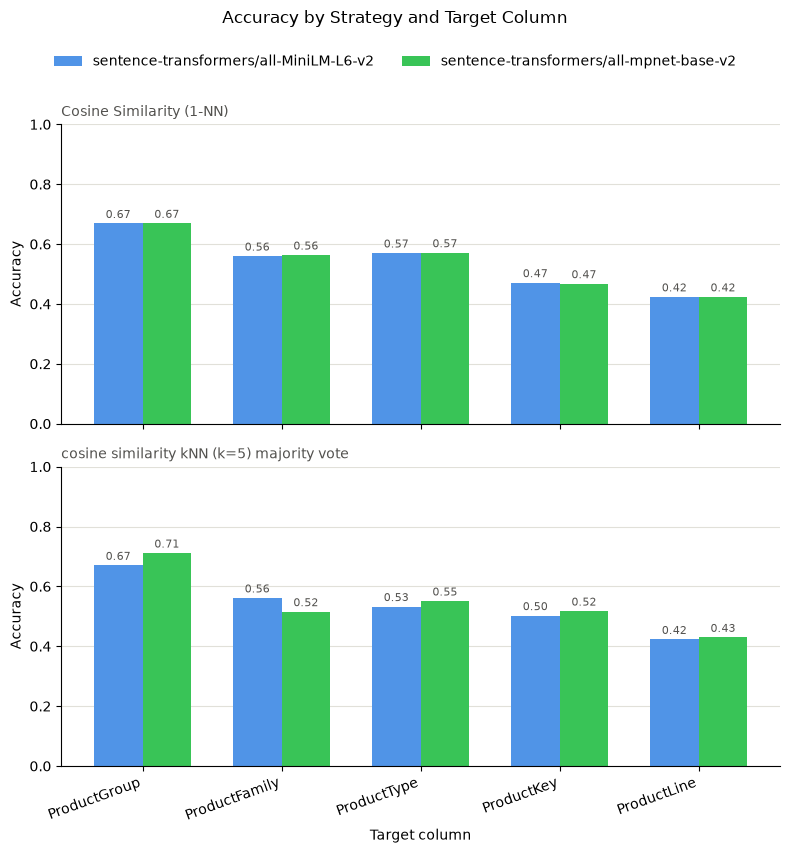

In [69]:
# Plot the comparison of model accuracies
import matplotlib.pyplot as plt

combined_df = pd.DataFrame(results + knn_results)

strategies = combined_df["Strategy"].unique()
model_names = combined_df["Model"].unique()
model_colors = {model_names[0]: "#5094e7", model_names[1]: "#39c457"}  # fixed categorical slots 1, 2
width = 0.35
x = np.arange(len(target_cols))

fig, axes = plt.subplots(len(strategies), 1, figsize=(8, 4 * len(strategies)), sharex=True)

for ax, strategy in zip(axes, strategies):
    strategy_df = combined_df[combined_df["Strategy"] == strategy]

    for i, model_name in enumerate(model_names):
        group = strategy_df[strategy_df["Model"] == model_name].set_index("target_col").reindex(target_cols)
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, group["Accuracy"], width, label=model_name, color=model_colors[model_name])
        ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, color="#52514e")

    ax.set_title(strategy, loc="left", fontsize=10, color="#52514e")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)

axes[-1].set_xlabel("Target column")
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(target_cols, rotation=20, ha="right")
fig.legend(list(model_names), loc="upper center", ncol=len(model_names), bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.suptitle("Accuracy by Strategy and Target Column", y=1.06)
plt.tight_layout()
plt.show()

In [70]:
# define function to compute top-3 accuracy for both strategies
def topk_accuracy(dataset, target_cols, encoded, train_idx, test_idx, k=5, retrieval_window=50):
    """Top-3 accuracy for the 1-NN retrieval strategy and the k-NN majority-vote strategy.

    Checks whether the true label is among the strategy's top 3 ranked candidate labels
    (by best similarity for 1-NN, by vote count then similarity for k-NN).
    """
    topk_results = []
    for target_col in target_cols:
        train_labels = np.array(dataset.loc[train_idx, target_col].tolist())
        test_labels = np.array(dataset.loc[test_idx, target_col].tolist())

        for model_name, (train_vectors, test_vectors) in encoded.items():
            print(f"=== Model: {model_name} | target_col: {target_col} ===")
            similarities = test_vectors @ train_vectors.T

            # Strategy: Cosine Similarity (1-NN) — rank distinct labels by best-matching neighbor
            window_indices = np.argsort(-similarities, axis=1)[:, :retrieval_window]
            hits = 0
            for row, true_label in zip(window_indices, test_labels):
                seen = []
                for lbl in train_labels[row]:
                    if lbl not in seen:
                        seen.append(lbl)
                        if len(seen) == 3:
                            break
                if true_label in seen:
                    hits += 1
            topk_results.append(
                {
                    "Strategy": "Cosine Similarity (1-NN)",
                    "Model": model_name,
                    "target_col": target_col,
                    "top_k": "Top-3",
                    "Accuracy": hits / len(test_labels),
                }
            )

            # Strategy: cosine similarity kNN (k=5) majority vote — rank candidates by vote
            # count within the k neighbors, tie-broken by summed similarity
            top_k_indices = np.argpartition(-similarities, kth=k - 1, axis=1)[:, :k]
            hits = 0
            for row_indices, row_sims, true_label in zip(top_k_indices, similarities, test_labels):
                neighbor_labels = train_labels[row_indices]
                neighbor_scores = row_sims[row_indices]
                vote_counts = Counter(neighbor_labels)
                ranked = sorted(
                    vote_counts.keys(),
                    key=lambda lbl: (vote_counts[lbl], neighbor_scores[neighbor_labels == lbl].sum()),
                    reverse=True,
                )
                top3 = ranked[:3]
                if true_label in top3:
                    hits += 1
            topk_results.append(
                {
                    "Strategy": f"cosine similarity kNN (k={k}) majority vote",
                    "Model": model_name,
                    "target_col": target_col,
                    "top_k": "Top-3",
                    "Accuracy": hits / len(test_labels),
                }
            )

    return topk_results

In [71]:
topk_results = topk_accuracy(dataset, target_cols, encoded, train_idx, test_idx, k=5)
topk_df = pd.DataFrame(topk_results)
topk_df

=== Model: sentence-transformers/all-MiniLM-L6-v2 | target_col: ProductGroup ===
=== Model: sentence-transformers/all-mpnet-base-v2 | target_col: ProductGroup ===
=== Model: sentence-transformers/all-MiniLM-L6-v2 | target_col: ProductFamily ===
=== Model: sentence-transformers/all-mpnet-base-v2 | target_col: ProductFamily ===
=== Model: sentence-transformers/all-MiniLM-L6-v2 | target_col: ProductType ===
=== Model: sentence-transformers/all-mpnet-base-v2 | target_col: ProductType ===
=== Model: sentence-transformers/all-MiniLM-L6-v2 | target_col: ProductKey ===
=== Model: sentence-transformers/all-mpnet-base-v2 | target_col: ProductKey ===
=== Model: sentence-transformers/all-MiniLM-L6-v2 | target_col: ProductLine ===
=== Model: sentence-transformers/all-mpnet-base-v2 | target_col: ProductLine ===


,Strategy,Model,target_col,top_k,Accuracy
0,Cosine Similarity (1-NN),sentence-transformers/all-MiniLM-L6-v2,ProductGroup,Top-3,0.861816
1,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-MiniLM-L6-v2,ProductGroup,Top-3,0.829102
2,Cosine Similarity (1-NN),sentence-transformers/all-mpnet-base-v2,ProductGroup,Top-3,0.817871
3,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-mpnet-base-v2,ProductGroup,Top-3,0.847168
4,Cosine Similarity (1-NN),sentence-transformers/all-MiniLM-L6-v2,ProductFamily,Top-3,0.735840
5,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-MiniLM-L6-v2,ProductFamily,Top-3,0.726074
6,Cosine Similarity (1-NN),sentence-transformers/all-mpnet-base-v2,ProductFamily,Top-3,0.711914
7,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-mpnet-base-v2,ProductFamily,Top-3,0.654297
8,Cosine Similarity (1-NN),sentence-transformers/all-MiniLM-L6-v2,ProductType,Top-3,0.843750
9,cosine similarity kNN (k=5) majority vote,sentence-transformers/all-MiniLM-L6-v2,ProductType,Top-3,0.789551


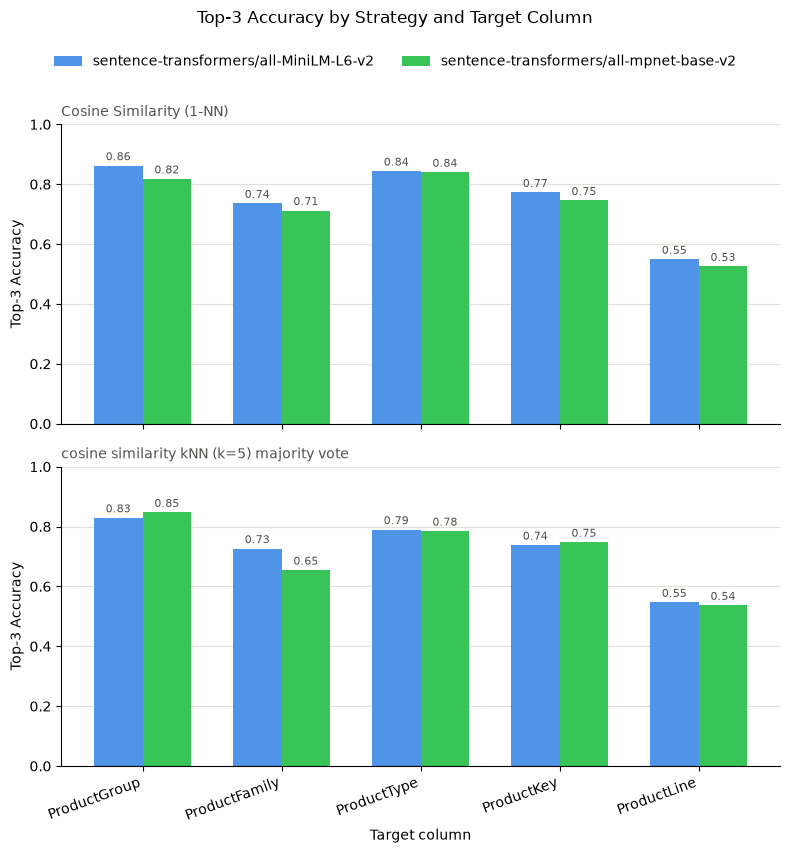

In [72]:
# Plot Top-3 accuracy for each strategy
model_names = topk_df["Model"].unique()
model_colors = {model_names[0]: "#5094e7", model_names[1]: "#39c457"}  # fixed categorical slots 1, 2
width = 0.35
x = np.arange(len(target_cols))
strategies = topk_df["Strategy"].unique()

fig, axes = plt.subplots(len(strategies), 1, figsize=(8, 4 * len(strategies)), sharex=True)

for ax, strategy in zip(axes, strategies):
    strategy_df = topk_df[(topk_df["Strategy"] == strategy) & (topk_df["top_k"] == "Top-3")]

    for i, model_name in enumerate(model_names):
        group = strategy_df[strategy_df["Model"] == model_name].set_index("target_col").reindex(target_cols)
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, group["Accuracy"], width, label=model_name, color=model_colors[model_name])
        ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, color="#52514e")

    ax.set_title(strategy, loc="left", fontsize=10, color="#52514e")
    ax.set_ylabel("Top-3 Accuracy")
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)

axes[-1].set_xlabel("Target column")
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(target_cols, rotation=20, ha="right")
fig.legend(list(model_names), loc="upper center", ncol=len(model_names), bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.suptitle("Top-3 Accuracy by Strategy and Target Column", y=1.06)
plt.tight_layout()
plt.show()